# 🔍 **End-to-End Fraud Detection Pipeline — Deep Learning Version**
---
👤 **Author Profile**
* Name: Mohamad Faisal Bashir
* Class: TK-47-04
* NIM: 101032300036
---
### 📖 **Task Overview:**
In this assignment, you will build an end-to-end fraud detection, You will work with both the transaction and identity tables, perform data cleaning and preprocessing, handle missing values and class imbalance, and engineer or select relevant features. You are required to implement deep learning models to predict the probability that a transaction is fraudulent (isFraud). The workflow should cover data preprocessing, model training, hyperparameter tuning (using Optuna), evaluation using appropriate metrics, and Tracking machine learning using MLFlow.

---
### 📌 **Workflow Pipeline:**

1. **Environment Setup & Library Imports**
2. **Data Loading & Initial Exploration (EDA)**
3. **Data Cleaning & Memory Optimization**
4. **Feature Engineering & Feature Selection**
5. **Train / Validation / Test Split**
6. **Preprocessing for Deep Learning**
7. **Handling Class Imbalance with SMOTE / SMOTENC**
8. **Deep Learning Model Architecture**
9. **Optuna Hyperparameter Tuning + MLflow Tracking**
10. **Final Model Training**
11. **Model Evaluation**
12. **Save Model, Preprocessing Artifacts, and Prediction Output**

---
### ☁️ **AzureML Development Notes:**
The notebook is designed to run in AzureML Notebook / Compute Instance. MLflow will log locally by default, and when executed inside an AzureML environment with MLflow tracking configured, the experiment can be tracked in the AzureML workspace.

## 0. Setup & Install Dependencies

In [1]:
%pip install tensorflow optuna mlflow azureml-mlflow scikit-learn imbalanced-learn pandas numpy matplotlib seaborn plotly joblib --quiet

Note: you may need to restart the kernel to use updated packages.


Installs all non-standard dependencies required by the deep learning pipeline. `tensorflow` is used to build the tabular neural network, `imbalanced-learn` provides SMOTE/SMOTENC for class imbalance handling, `optuna` handles automated hyperparameter tuning, and `mlflow` with `azureml-mlflow` enables experiment tracking in an AzureML-compatible workflow. The remaining libraries support data manipulation, preprocessing, visualization, and artifact serialization.

In [2]:
import os
import gc
import glob
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

import optuna
import mlflow
import mlflow.tensorflow

warnings.filterwarnings("ignore")
sns.set_context("notebook")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Semua library berhasil di-import!")
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("MLflow tracking URI:", mlflow.get_tracking_uri())

2026-06-20 13:33:12.488223: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/anaconda/envs/azureml_py38_PT_TF/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Semua library berhasil di-import!
TensorFlow version: 2.20.0
GPU devices: []
MLflow tracking URI: azureml://southeastasia.api.azureml.ms/mlflow/v1.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas


2026-06-20 13:33:27.657854: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Loads the complete library stack used across the notebook. The key difference from the previous machine learning version is the use of TensorFlow/Keras instead of LightGBM, with SMOTE/SMOTENC added to support class imbalance handling. Reproducibility is improved by fixing random seeds across Python, NumPy, and TensorFlow. The GPU check is included because AzureML Compute may provide either CPU-only or GPU-backed environments.

## 1. Configuration

In [3]:
# =========================
# Global Configuration
# =========================

BASE_PATH = "./folder-data"
DATA_FILE_NAME = "train_transaction.csv"
TARGET_COL = "isFraud"
ID_COL = "TransactionID"

# Preprocessing / feature selection
MISSING_DROP_THRESHOLD = 0.90      # Drop features with >90% missing values based on training split only
MIN_CATEGORY_COUNT = 10           # Rare category threshold
MAX_CATEGORY_LEVELS = 1000        # Cap category levels per categorical feature
MAX_NUMERIC_FEATURES = None       # Set to an integer if AzureML memory is limited, e.g. 250

# Split configuration
TEST_SIZE = 0.15
VAL_SIZE = 0.15                   # Final split: 70% train, 15% validation, 15% test
RANDOM_STATE = 42

# Class imbalance configuration
USE_SMOTE = True                   # Apply SMOTE/SMOTENC only to the training split
SMOTE_SAMPLING_STRATEGY = 0.30     # Minority/majority ratio after resampling; set 1.0 for full balance
SMOTE_K_NEIGHBORS = 5              # Automatically reduced if fraud samples are too few

# Optuna / training configuration
N_TRIALS = 30                     # Increase to 20-50 for stronger tuning if compute budget allows
EPOCHS_PER_TRIAL = 10
FINAL_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 3

# To keep tuning manageable on AzureML, tuning can use a stratified sample.
# The final model is still trained using the full training split.
USE_TUNING_SAMPLE = True
TUNE_SAMPLE_SIZE = 120_000

# Output directory captured by AzureML jobs and useful for local runs as well
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ Configuration loaded.")

✅ Configuration loaded.


This configuration cell centralizes the main operational parameters. The notebook uses a holdout test split because only `train_transaction.csv` is available. Optuna tuning is intentionally capped by default to avoid excessive AzureML compute cost, while the final model is trained on the SMOTE-resampled training split. If more compute is available, `N_TRIALS`, `EPOCHS_PER_TRIAL`, and `FINAL_EPOCHS` can be increased.

`SMOTE_SAMPLING_STRATEGY` is set to `0.30` by default to make the oversampling process more memory-friendly in AzureML. It can be increased to `1.0` if full minority-majority balancing is required and compute resources are sufficient.


## 2. Data Ingestion & Memory Optimization

In [4]:
def locate_dataset(file_name: str = DATA_FILE_NAME) -> str:
    """
    Locate train_transaction.csv in common local and AzureML notebook paths.
    The function avoids depending on a single hard-coded path.
    """
    env_candidates = [
        os.environ.get("AZUREML_DATAREFERENCE_train_transaction"),
        os.environ.get("AZUREML_DATAREFERENCE_train_data"),
        os.environ.get("AZUREML_DATA_PATH"),
        os.environ.get("INPUT_DATA_PATH"),
    ]

    candidate_paths = [
        Path(BASE_PATH) / file_name,
        Path(".") / file_name,
        Path("/mnt/data") / file_name,
    ]

    for env_path in env_candidates:
        if env_path:
            p = Path(env_path)
            candidate_paths.append(p / file_name if p.is_dir() else p)

    for p in candidate_paths:
        if p.exists():
            return str(p)

    # Fallback: search only practical roots to avoid scanning the whole VM.
    search_roots = [Path("."), Path("/mnt/data")]
    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.glob(f"**/{file_name}"))

    if matches:
        return str(matches[0])

    raise FileNotFoundError(
        f"{file_name} tidak ditemukan. Upload file ke folder notebook, "
        f"atau letakkan di {BASE_PATH}/{file_name}."
    )


def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    """
    Downcast numeric columns to reduce RAM usage.
    This is important because IEEE-CIS transaction data is relatively large.
    """
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage before optimization: {start_mem:.2f} MB")

    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_numeric_dtype(col_type):
            if df[col].isnull().all():
                continue

            c_min = df[col].min()
            c_max = df[col].max()

            if pd.api.types.is_integer_dtype(col_type):
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                df[col] = pd.to_numeric(df[col], downcast="float")

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    reduction = 100 * (start_mem - end_mem) / start_mem if start_mem > 0 else 0

    print(f"Memory usage after optimization : {end_mem:.2f} MB")
    print(f"Memory reduced by               : {reduction:.1f}%")
    return df


train_path = locate_dataset(DATA_FILE_NAME)
print("Dataset path:", train_path)

train = pd.read_csv(train_path)
train = reduce_mem_usage(train)

print("\n✅ Data berhasil dimuat.")
print("Shape:", train.shape)
display(train.head())

Dataset path: train_transaction.csv
Memory usage before optimization: 485.85 MB
Memory usage after optimization : 284.95 MB
Memory reduced by               : 41.3%

✅ Data berhasil dimuat.
Shape: (138133, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


This cell handles single-table ingestion because the available dataset is limited to `train_transaction.csv`. The previous machine learning notebook merged transaction and identity tables, but this deep learning version intentionally excludes identity-table loading to match the current dataset constraint.

The `reduce_mem_usage` function downcasts numerical columns to smaller data types where possible. This is important in AzureML because tabular fraud datasets can consume substantial memory, especially when multiple preprocessing arrays are created for neural network training.

## 3. Exploratory Data Analysis (EDA)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138133 entries, 0 to 138132
Columns: 394 entries, TransactionID to V339
dtypes: float32(376), int16(1), int32(2), int8(1), object(14)
memory usage: 214.3+ MB


None


Target distribution:


isFraud
0    134561
1      3572
Name: count, dtype: int64

isFraud
0    97.4141
1     2.5859
Name: proportion, dtype: float64

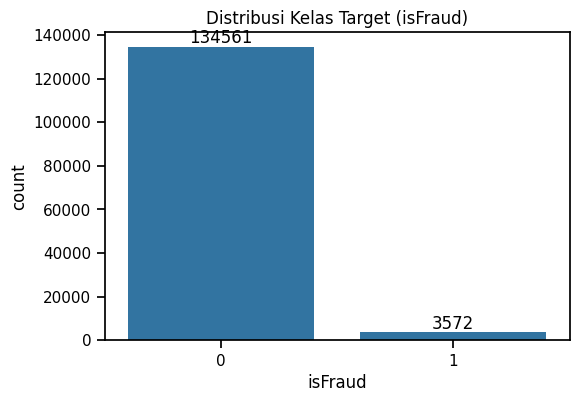

Persentase transaksi Fraud: 2.59%

Top 15 Kolom dengan Missing Value Tertinggi (%):


,missing_percentage
D7,93.454859
dist2,91.306929
D13,89.568749
D12,88.412617
D14,88.089016
D6,86.137997
M7,84.306429
M9,84.306429
M8,84.306429
D8,78.449755


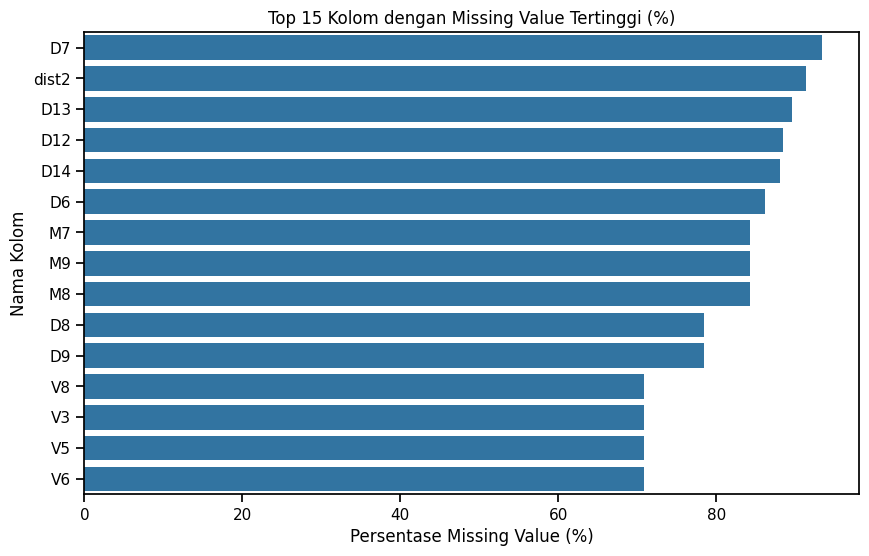

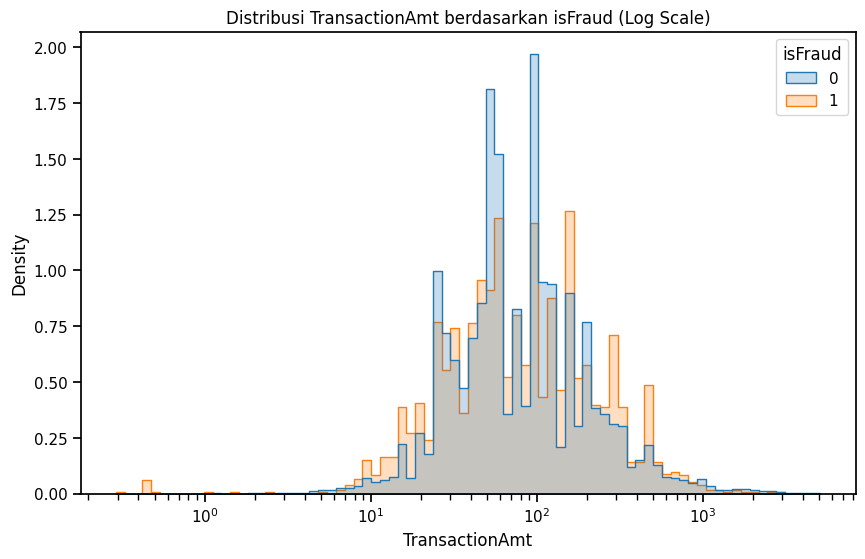

In [5]:
print("Dataset Info:")
display(train.info())

print("\nTarget distribution:")
display(train[TARGET_COL].value_counts(dropna=False))
display(train[TARGET_COL].value_counts(normalize=True, dropna=False).mul(100).round(4))

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=TARGET_COL, data=train)
plt.title("Distribusi Kelas Target (isFraud)")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom"
    )
plt.show()

fraud_ratio = train[TARGET_COL].mean() * 100
print(f"Persentase transaksi Fraud: {fraud_ratio:.2f}%")

# Missing value analysis
missing_val = train.isnull().mean().mul(100).sort_values(ascending=False)
top_missing = missing_val.head(15)

print("\nTop 15 Kolom dengan Missing Value Tertinggi (%):")
display(top_missing.to_frame("missing_percentage"))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.title("Top 15 Kolom dengan Missing Value Tertinggi (%)")
plt.xlabel("Persentase Missing Value (%)")
plt.ylabel("Nama Kolom")
plt.show()

# Transaction amount distribution
if "TransactionAmt" in train.columns:
    eda_sample = train.sample(n=min(len(train), 100_000), random_state=SEED)

    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=eda_sample,
        x="TransactionAmt",
        hue=TARGET_COL,
        bins=80,
        log_scale=True,
        element="step",
        stat="density",
        common_norm=False
    )
    plt.title("Distribusi TransactionAmt berdasarkan isFraud (Log Scale)")
    plt.xlabel("TransactionAmt")
    plt.ylabel("Density")
    plt.show()

Three analyses are performed before modeling. First, the class distribution confirms the imbalance between normal and fraudulent transactions. Second, the missing-value profile identifies features that may be too sparse for reliable training. Third, the transaction amount distribution is visualized on a log scale because transaction values usually span several orders of magnitude. These findings directly influence class weighting, missing-value handling, and feature selection in the next stages.

## 4. Feature Engineering

In [6]:
def add_transaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create transaction-based features from train_transaction.csv only.
    No identity-table features are used in this notebook.
    """
    df = df.copy()

    # Sanitize column names for downstream tools
    df.columns = df.columns.str.replace("-", "_", regex=False)

    if "TransactionDT" in df.columns:
        # TransactionDT is a time delta in seconds, not a real calendar timestamp.
        df["Transaction_Day"] = np.floor((df["TransactionDT"] / (3600 * 24) - 1) % 7)
        df["Transaction_Hour"] = np.floor(df["TransactionDT"] / 3600) % 24

    if "TransactionAmt" in df.columns:
        df["TransactionAmt_log1p"] = np.log1p(df["TransactionAmt"])

    # Simple email-domain features if available in transaction table.
    for email_col in ["P_emaildomain", "R_emaildomain"]:
        if email_col in df.columns:
            values = df[email_col].astype("string")
            df[f"{email_col}_suffix"] = values.str.split(".").str[-1].fillna("__MISSING__")
            df[f"{email_col}_provider"] = values.str.split(".").str[0].fillna("__MISSING__")

    return df


train_fe = add_transaction_features(train)

print("Shape before feature engineering:", train.shape)
print("Shape after feature engineering :", train_fe.shape)

new_cols = sorted(set(train_fe.columns) - set(train.columns))
print("New engineered features:", new_cols)

del train
gc.collect()

Shape before feature engineering: (138133, 394)
Shape after feature engineering : (138133, 401)
New engineered features: ['P_emaildomain_provider', 'P_emaildomain_suffix', 'R_emaildomain_provider', 'R_emaildomain_suffix', 'TransactionAmt_log1p', 'Transaction_Day', 'Transaction_Hour']


40

`TransactionDT` is converted into day-of-week and hour-of-day features because the original column is a relative time delta rather than a standard timestamp. `TransactionAmt_log1p` is added to make the highly skewed transaction amount more neural-network friendly. If email-domain columns exist, simple provider and suffix features are extracted to preserve useful categorical information from the transaction table.

## 5. Train / Validation / Test Split

In [7]:
if TARGET_COL not in train_fe.columns:
    raise ValueError(f"Target column '{TARGET_COL}' tidak ditemukan pada dataset.")

y = train_fe[TARGET_COL].astype(np.int32)

drop_base_cols = [TARGET_COL]
if ID_COL in train_fe.columns:
    drop_base_cols.append(ID_COL)

X = train_fe.drop(columns=drop_base_cols)

# First split: reserve test set
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split: reserve validation set from remaining data.
# VAL_SIZE is absolute ratio, so convert it relative to the remaining train portion.
relative_val_size = VAL_SIZE / (1.0 - TEST_SIZE)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=relative_val_size,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Shape Data Train:", X_train_raw.shape)
print("Shape Data Val  :", X_val_raw.shape)
print("Shape Data Test :", X_test_raw.shape)

print("\nDistribusi Target Train:")
display(y_train.value_counts(normalize=True).mul(100).round(4))

print("\nDistribusi Target Val:")
display(y_val.value_counts(normalize=True).mul(100).round(4))

print("\nDistribusi Target Test:")
display(y_test.value_counts(normalize=True).mul(100).round(4))

del X, train_fe
gc.collect()

Shape Data Train: (96693, 399)
Shape Data Val  : (20720, 399)
Shape Data Test : (20720, 399)

Distribusi Target Train:


isFraud
0    97.4145
1     2.5855
Name: proportion, dtype: float64


Distribusi Target Val:


isFraud
0    97.4131
1     2.5869
Name: proportion, dtype: float64


Distribusi Target Test:


isFraud
0    97.4131
1     2.5869
Name: proportion, dtype: float64

0

A stratified 70/15/15 split is used because fraud detection is highly imbalanced. The validation set is used by Optuna to compare candidate neural network configurations, while the test set is kept untouched until the final evaluation. This separation reduces the risk of overestimating performance after hyperparameter tuning.

## 6. Feature Selection & Preprocessing for Deep Learning

In [8]:
# Drop high-missing and constant columns based on training data only to avoid leakage.
missing_ratio_train = X_train_raw.isnull().mean()
drop_missing_cols = missing_ratio_train[missing_ratio_train > MISSING_DROP_THRESHOLD].index.tolist()

constant_cols = [
    col for col in X_train_raw.columns
    if X_train_raw[col].nunique(dropna=False) <= 1
]

drop_cols = sorted(set(drop_missing_cols + constant_cols))

print(f"Kolom di-drop karena missing value > {MISSING_DROP_THRESHOLD:.0%}: {len(drop_missing_cols)}")
print(f"Kolom di-drop karena constant/near-empty          : {len(constant_cols)}")
print(f"Total kolom di-drop                              : {len(drop_cols)}")

X_train_raw = X_train_raw.drop(columns=drop_cols)
X_val_raw = X_val_raw.drop(columns=drop_cols)
X_test_raw = X_test_raw.drop(columns=drop_cols)

# Detect categorical and numerical columns
cat_cols = X_train_raw.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = [col for col in X_train_raw.columns if col not in cat_cols]

# Optional numeric feature cap if AzureML memory is limited
if MAX_NUMERIC_FEATURES is not None and len(num_cols) > MAX_NUMERIC_FEATURES:
    # Select numeric features with the lowest missing ratio first.
    numeric_missing = X_train_raw[num_cols].isnull().mean().sort_values()
    num_cols = numeric_missing.head(MAX_NUMERIC_FEATURES).index.tolist()

selected_cols = num_cols + cat_cols
X_train_raw = X_train_raw[selected_cols]
X_val_raw = X_val_raw[selected_cols]
X_test_raw = X_test_raw[selected_cols]

print(f"Jumlah fitur numerik    : {len(num_cols)}")
print(f"Jumlah fitur kategorikal: {len(cat_cols)}")
print(f"Total fitur digunakan   : {len(selected_cols)}")

Kolom di-drop karena missing value > 90%: 2
Kolom di-drop karena constant/near-empty          : 1
Total kolom di-drop                              : 3
Jumlah fitur numerik    : 378
Jumlah fitur kategorikal: 18
Total fitur digunakan   : 396


Feature selection is performed using only the training split. Columns with excessive missing values are removed because they provide limited stable signal and can increase memory cost. Constant columns are also removed because they do not help a neural network distinguish fraud from non-fraud. The remaining columns are separated into numerical and categorical groups because each group requires a different preprocessing strategy.

In [9]:
# =========================
# Numerical preprocessing
# =========================

num_imputer = SimpleImputer(strategy="median")
num_scaler = StandardScaler()

if len(num_cols) > 0:
    X_train_num = num_imputer.fit_transform(X_train_raw[num_cols])
    X_val_num = num_imputer.transform(X_val_raw[num_cols])
    X_test_num = num_imputer.transform(X_test_raw[num_cols])

    X_train_num = num_scaler.fit_transform(X_train_num).astype("float32")
    X_val_num = num_scaler.transform(X_val_num).astype("float32")
    X_test_num = num_scaler.transform(X_test_num).astype("float32")
else:
    X_train_num = np.zeros((len(X_train_raw), 0), dtype="float32")
    X_val_num = np.zeros((len(X_val_raw), 0), dtype="float32")
    X_test_num = np.zeros((len(X_test_raw), 0), dtype="float32")


# =========================
# Categorical preprocessing
# =========================

MISSING_TOKEN = "__MISSING__"
RARE_TOKEN = "__RARE__"
UNKNOWN_INDEX = 0

category_maps = {}
cat_cardinalities = []

def fit_category_maps(df: pd.DataFrame, cat_columns: list[str]) -> dict:
    maps = {}

    for col in cat_columns:
        s = df[col].astype("string").fillna(MISSING_TOKEN)
        counts = s.value_counts(dropna=False)

        kept_categories = counts[counts >= MIN_CATEGORY_COUNT].index.tolist()

        # Cap levels to prevent extremely large embeddings.
        if len(kept_categories) > MAX_CATEGORY_LEVELS - 1:
            kept_categories = kept_categories[:MAX_CATEGORY_LEVELS - 1]

        if RARE_TOKEN not in kept_categories:
            kept_categories.append(RARE_TOKEN)

        maps[col] = {category: idx + 1 for idx, category in enumerate(kept_categories)}

    return maps


def transform_categories(df: pd.DataFrame, cat_columns: list[str], maps: dict) -> np.ndarray:
    if len(cat_columns) == 0:
        return np.zeros((len(df), 0), dtype="int32")

    encoded_columns = []

    for col in cat_columns:
        s = df[col].astype("string").fillna(MISSING_TOKEN)
        mapping = maps[col]

        # Categories not seen or too rare during training are sent to RARE_TOKEN if available.
        rare_index = mapping.get(RARE_TOKEN, UNKNOWN_INDEX)
        encoded = s.map(mapping).fillna(rare_index).astype("int32").to_numpy()
        encoded_columns.append(encoded)

    return np.column_stack(encoded_columns).astype("int32")


category_maps = fit_category_maps(X_train_raw, cat_cols)
cat_cardinalities = [len(category_maps[col]) + 1 for col in cat_cols]

X_train_cat = transform_categories(X_train_raw, cat_cols, category_maps)
X_val_cat = transform_categories(X_val_raw, cat_cols, category_maps)
X_test_cat = transform_categories(X_test_raw, cat_cols, category_maps)

print("Numeric train array    :", X_train_num.shape)
print("Categorical train array:", X_train_cat.shape)
print("Categorical cardinalities:", cat_cardinalities[:10], "..." if len(cat_cardinalities) > 10 else "")

Numeric train array    : (96693, 378)
Categorical train array: (96693, 18)
Categorical cardinalities: [7, 6, 4, 58, 49, 4, 5, 5, 6, 5] ...


Numerical features are imputed using the median and then standardized. This is important because neural networks are sensitive to feature scale. Categorical features are not treated as ordinal numbers. Instead, each category is mapped into an integer index and later passed into embedding layers. Rare and unseen categories are grouped to avoid overly large embedding tables and to improve generalization.

## 7. Handling Class Imbalance with SMOTE / SMOTENC

In [10]:
def build_class_weight_dict(y_values):
    """
    Compute balanced class weights from a target array.
    The returned dictionary can be passed directly to Keras model.fit().
    """
    y_array = np.asarray(y_values).astype(np.int32)
    classes = np.unique(y_array)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_array
    )
    return {int(cls): float(weight) for cls, weight in zip(classes, weights)}


original_class_weight_dict = build_class_weight_dict(y_train)

print("Original training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nOriginal class weights:")
print(original_class_weight_dict)


def apply_smote_resampling(X_num: np.ndarray, X_cat: np.ndarray, y_values):
    """
    Apply SMOTE only on the training split after preprocessing.

    - If categorical features exist, SMOTENC is used so categorical indices are not interpolated.
    - If only numerical features exist, regular SMOTE is used.
    - Validation and test data are never resampled to avoid data leakage.
    """
    y_array = np.asarray(y_values).astype(np.int32)

    if not USE_SMOTE:
        print("\nSMOTE disabled. Using original training data.")
        return X_num, X_cat, y_array

    class_counts = pd.Series(y_array).value_counts().sort_index()
    if len(class_counts) < 2:
        print("\nSMOTE skipped because only one class is present in the training data.")
        return X_num, X_cat, y_array

    majority_count = int(class_counts.max())
    minority_count = int(class_counts.min())
    current_ratio = minority_count / majority_count

    if current_ratio >= SMOTE_SAMPLING_STRATEGY:
        print(
            f"\nSMOTE skipped because current minority/majority ratio "
            f"({current_ratio:.4f}) is already >= target ratio ({SMOTE_SAMPLING_STRATEGY})."
        )
        return X_num, X_cat, y_array

    if minority_count <= 1:
        print("\nSMOTE skipped because the minority class has too few samples.")
        return X_num, X_cat, y_array

    k_neighbors = min(SMOTE_K_NEIGHBORS, minority_count - 1)

    X_combined = np.hstack([
        X_num.astype("float32"),
        X_cat.astype("float32")
    ])

    categorical_indices = list(range(X_num.shape[1], X_combined.shape[1]))

    if X_cat.shape[1] > 0:
        sampler = SMOTENC(
            categorical_features=categorical_indices,
            sampling_strategy=SMOTE_SAMPLING_STRATEGY,
            random_state=SEED,
            k_neighbors=k_neighbors
        )
        sampler_name = "SMOTENC"
    else:
        sampler = SMOTE(
            sampling_strategy=SMOTE_SAMPLING_STRATEGY,
            random_state=SEED,
            k_neighbors=k_neighbors
        )
        sampler_name = "SMOTE"

    print(f"\nApplying {sampler_name} on training data only...")
    print(f"Target minority/majority ratio: {SMOTE_SAMPLING_STRATEGY}")
    print(f"k_neighbors used               : {k_neighbors}")

    X_resampled, y_resampled = sampler.fit_resample(X_combined, y_array)

    n_num = X_num.shape[1]
    X_resampled_num = X_resampled[:, :n_num].astype("float32")

    if X_cat.shape[1] > 0:
        X_resampled_cat = np.rint(X_resampled[:, n_num:]).astype("int32")
    else:
        X_resampled_cat = np.zeros((len(X_resampled), 0), dtype="int32")

    return X_resampled_num, X_resampled_cat, y_resampled.astype(np.int32)


X_train_balanced_num, X_train_balanced_cat, y_train_balanced = apply_smote_resampling(
    X_train_num,
    X_train_cat,
    y_train
)

class_weight_dict = build_class_weight_dict(y_train_balanced)

print("\nTraining class distribution after SMOTE/SMOTENC:")
print(pd.Series(y_train_balanced).value_counts().sort_index())
print("\nClass weights used during neural network training:")
print(class_weight_dict)

print("\nArray shapes after class imbalance handling:")
print("Balanced numeric train array    :", X_train_balanced_num.shape)
print("Balanced categorical train array:", X_train_balanced_cat.shape)
print("Balanced target array           :", y_train_balanced.shape)


Original training class distribution:
isFraud
0    94193
1     2500
Name: count, dtype: int64

Original class weights:
{0: 0.5132706252056947, 1: 19.3386}

Applying SMOTENC on training data only...
Target minority/majority ratio: 0.3
k_neighbors used               : 5

Training class distribution after SMOTE/SMOTENC:
0    94193
1    28257
Name: count, dtype: int64

Class weights used during neural network training:
{0: 0.6499952225749259, 1: 2.1667197508581943}

Array shapes after class imbalance handling:
Balanced numeric train array    : (122450, 378)
Balanced categorical train array: (122450, 18)
Balanced target array           : (122450,)


Fraud detection is a severe class imbalance problem because fraudulent transactions usually represent only a small percentage of the dataset. In this notebook, SMOTE is applied only to the training split after preprocessing. When categorical features are present, `SMOTENC` is used instead of regular SMOTE so that categorical feature indices are treated as categories rather than interpolated numeric values.

The validation and test sets are intentionally left in their original distribution to reflect realistic fraud detection performance. After SMOTE/SMOTENC, class weights are recalculated and still passed to the neural network. This makes the loss function sensitive to the remaining imbalance when `SMOTE_SAMPLING_STRATEGY` is set below full balancing for AzureML memory efficiency.

## 8. TensorFlow Dataset Builder

In [11]:
def make_tf_dataset(
    X_num: np.ndarray,
    X_cat: np.ndarray,
    y_values=None,
    batch_size: int = 1024,
    shuffle: bool = False
):
    inputs = {
        "numeric": X_num.astype("float32"),
        "categorical": X_cat.astype("int32")
    }

    if y_values is None:
        ds = tf.data.Dataset.from_tensor_slices(inputs)
    else:
        y_array = np.asarray(y_values).astype("float32")
        ds = tf.data.Dataset.from_tensor_slices((inputs, y_array))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(len(X_num), 100_000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def stratified_sample_arrays(X_num, X_cat, y_values, sample_size, random_state=SEED):
    """
    Create a stratified sample for faster Optuna tuning.
    """
    y_series = pd.Series(np.asarray(y_values))
    if sample_size is None or sample_size >= len(y_series):
        return X_num, X_cat, np.asarray(y_values)

    sampled_indices = (
        y_series
        .groupby(y_series)
        .sample(
            frac=sample_size / len(y_series),
            random_state=random_state
        )
        .index
        .to_numpy()
    )

    # If rounding makes the sample slightly smaller, top it up randomly.
    if len(sampled_indices) < sample_size:
        remaining = np.setdiff1d(np.arange(len(y_series)), sampled_indices)
        extra = np.random.default_rng(random_state).choice(
            remaining,
            size=sample_size - len(sampled_indices),
            replace=False
        )
        sampled_indices = np.concatenate([sampled_indices, extra])

    return X_num[sampled_indices], X_cat[sampled_indices], np.asarray(y_values)[sampled_indices]


if USE_TUNING_SAMPLE:
    X_tune_num, X_tune_cat, y_tune = stratified_sample_arrays(
        X_train_balanced_num,
        X_train_balanced_cat,
        y_train_balanced,
        sample_size=min(TUNE_SAMPLE_SIZE, len(y_train_balanced)),
        random_state=SEED
    )
else:
    X_tune_num, X_tune_cat, y_tune = X_train_balanced_num, X_train_balanced_cat, np.asarray(y_train_balanced)

print("Tuning numeric array    :", X_tune_num.shape)
print("Tuning categorical array:", X_tune_cat.shape)
print("Tuning target shape     :", y_tune.shape)
print("Tuning class distribution:")
print(pd.Series(y_tune).value_counts().sort_index())

Tuning numeric array    : (120000, 378)
Tuning categorical array: (120000, 18)
Tuning target shape     : (120000,)
Tuning class distribution:
0    92308
1    27692
Name: count, dtype: int64


TensorFlow datasets are built from two input branches: one for numerical features and one for categorical features. This structure matches the model architecture defined in the next section. A stratified tuning sample is also prepared to keep Optuna trials computationally manageable while maintaining the original fraud/non-fraud ratio.

## 9. Deep Learning Model Architecture

In [12]:
def build_tabular_dl_model(
    n_num_features: int,
    cat_cardinalities: list[int],
    hidden_units: list[int],
    dropout_rate: float,
    learning_rate: float,
    l2_reg: float,
    max_embedding_dim: int
) -> keras.Model:
    """
    Build a tabular deep learning model with:
    - Numerical input branch
    - Categorical embedding branch
    - Fully connected dense layers
    - Sigmoid output for fraud probability
    """
    numeric_input = keras.Input(shape=(n_num_features,), name="numeric")
    categorical_input = keras.Input(
        shape=(len(cat_cardinalities),),
        dtype="int32",
        name="categorical"
    )

    inputs_to_concat = [numeric_input]

    if len(cat_cardinalities) > 0:
        for idx, cardinality in enumerate(cat_cardinalities):
            emb_dim = int(min(max_embedding_dim, max(2, round(cardinality ** 0.25 * 4))))

            # Direct KerasTensor slicing avoids non-serializable Lambda layers.
            cat_slice = categorical_input[:, idx]

            emb = layers.Embedding(
                input_dim=cardinality,
                output_dim=emb_dim,
                embeddings_regularizer=regularizers.l2(l2_reg),
                name=f"emb_{cat_cols[idx]}"
            )(cat_slice)

            emb = layers.Flatten(name=f"flat_emb_{idx}")(emb)
            inputs_to_concat.append(emb)

    if len(inputs_to_concat) > 1:
        x = layers.Concatenate(name="concat_features")(inputs_to_concat)
    else:
        x = numeric_input

    x = layers.BatchNormalization(name="input_batch_norm")(x)

    for layer_idx, units in enumerate(hidden_units):
        x = layers.Dense(
            units,
            kernel_regularizer=regularizers.l2(l2_reg),
            name=f"dense_{layer_idx + 1}"
        )(x)
        x = layers.BatchNormalization(name=f"bn_{layer_idx + 1}")(x)
        x = layers.Activation("relu", name=f"relu_{layer_idx + 1}")(x)
        x = layers.Dropout(dropout_rate, name=f"dropout_{layer_idx + 1}")(x)

    output = layers.Dense(1, activation="sigmoid", name="fraud_probability")(x)

    model = keras.Model(
        inputs={"numeric": numeric_input, "categorical": categorical_input},
        outputs=output,
        name="Tabular_Fraud_Detection_DL"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.AUC(name="auc", curve="ROC"),
            keras.metrics.AUC(name="pr_auc", curve="PR"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ]
    )

    return model


preview_model = build_tabular_dl_model(
    n_num_features=X_train_num.shape[1],
    cat_cardinalities=cat_cardinalities,
    hidden_units=[128, 64],
    dropout_rate=0.30,
    learning_rate=1e-3,
    l2_reg=1e-6,
    max_embedding_dim=32
)

preview_model.summary()
tf.keras.backend.clear_session()

Model: "Tabular_Fraud_Detection_DL"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ categorical         │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None)            │          0 │ categorical[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_9          │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_10         │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_11         │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_12         │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_13         │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_14         │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_15         │ (None)            │          0 │ categorical[0][0] │
│ (GetItem)           │                   │            │                 

 Total params: 78,711 (307.46 KB)

 Trainable params: 77,313 (302.00 KB)

 Non-trainable params: 1,398 (5.46 KB)

The model architecture uses two input branches. Numerical features are fed directly after scaling, while categorical features are passed through embedding layers. The embedding approach allows the neural network to learn dense representations of categorical values instead of assuming an artificial ordinal relationship. Dense layers with batch normalization and dropout are used to improve training stability and reduce overfitting.

## 10. MLOps: Optuna Tuning + MLflow Tracking

In [13]:
# ============================================================
# 10. Hyperparameter Tuning with Optuna + MLflow
# ============================================================

# Pastikan tidak ada MLflow run lama yang masih aktif
while mlflow.active_run() is not None:
    mlflow.end_run()

mlflow.set_experiment("Fraud_Detection_Tabular_DL_Optuna")

optuna.logging.set_verbosity(optuna.logging.WARNING)


class OptunaPruningCallback(keras.callbacks.Callback):
    """
    Lightweight Keras pruning callback without requiring optuna-integration package.
    Callback ini digunakan untuk menghentikan trial Optuna yang performanya kurang baik.
    """
    def __init__(self, trial, monitor="val_auc"):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_score = logs.get(self.monitor)

        if current_score is None:
            return

        self.trial.report(float(current_score), step=epoch)

        if self.trial.should_prune():
            raise optuna.TrialPruned(f"Trial pruned at epoch {epoch}.")


def trial_params_to_model_config(params: dict) -> dict:
    """
    Mengubah parameter hasil sampling Optuna menjadi konfigurasi model Keras.
    """
    hidden_units = [params[f"units_l{i}"] for i in range(params["n_layers"])]

    return {
        "hidden_units": hidden_units,
        "dropout_rate": params["dropout_rate"],
        "learning_rate": params["learning_rate"],
        "l2_reg": params["l2_reg"],
        "max_embedding_dim": params["max_embedding_dim"],
    }


def log_class_weights_as_params(class_weight_dict: dict):
    """
    Menghindari mlflow.log_dict karena pada beberapa environment AzureML
    dapat memunculkan error azureml_artifacts_builder().
    Sebagai gantinya, class weight disimpan sebagai parameter MLflow.
    """
    for class_label, weight in class_weight_dict.items():
        mlflow.log_param(f"class_weight_{class_label}", float(weight))


def objective(trial: optuna.Trial) -> float:
    """
    Objective function untuk Optuna.
    Setiap trial akan membangun model neural network dengan kombinasi hyperparameter berbeda,
    kemudian dievaluasi menggunakan ROC-AUC pada validation set.
    """
    tf.keras.backend.clear_session()

    # -----------------------------
    # Hyperparameter search space
    # -----------------------------
    n_layers = trial.suggest_int("n_layers", 1, 3)

    for i in range(n_layers):
        trial.suggest_categorical(f"units_l{i}", [64, 128, 256, 384])

    trial.suggest_float("dropout_rate", 0.10, 0.50)
    trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    trial.suggest_float("l2_reg", 1e-7, 1e-4, log=True)
    trial.suggest_categorical("max_embedding_dim", [8, 16, 32, 64])
    batch_size = trial.suggest_categorical("batch_size", [512, 1024, 2048])

    model_config = trial_params_to_model_config(trial.params)

    # -----------------------------
    # TensorFlow Dataset
    # -----------------------------
    train_ds = make_tf_dataset(
        X_tune_num,
        X_tune_cat,
        y_tune,
        batch_size=batch_size,
        shuffle=True
    )

    val_ds = make_tf_dataset(
        X_val_num,
        X_val_cat,
        y_val,
        batch_size=batch_size,
        shuffle=False
    )

    # -----------------------------
    # MLflow Tracking per Trial
    # -----------------------------
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        mlflow.log_params(trial.params)

        mlflow.log_param("model_type", "Keras_Tabular_Neural_Network")
        mlflow.log_param("num_features", X_train_num.shape[1])
        mlflow.log_param("cat_features", X_train_cat.shape[1])
        mlflow.log_param("tuning_sample_size", len(y_tune))
        mlflow.log_param("use_smote", USE_SMOTE)
        mlflow.log_param("smote_sampling_strategy", SMOTE_SAMPLING_STRATEGY)

        # FIX ERROR:
        # Jangan pakai mlflow.log_dict(...) di AzureML environment ini.
        # Simpan class weight sebagai parameter biasa.
        log_class_weights_as_params(class_weight_dict)

        # -----------------------------
        # Build Model
        # -----------------------------
        model = build_tabular_dl_model(
            n_num_features=X_train_num.shape[1],
            cat_cardinalities=cat_cardinalities,
            **model_config
        )

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=EARLY_STOPPING_PATIENCE,
                restore_best_weights=True
            ),
            OptunaPruningCallback(trial, monitor="val_auc")
        ]

        # -----------------------------
        # Train Model
        # -----------------------------
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_PER_TRIAL,
            class_weight=class_weight_dict,
            callbacks=callbacks,
            verbose=0
        )

        # -----------------------------
        # Validation Evaluation
        # -----------------------------
        val_proba = model.predict(val_ds, verbose=0).ravel()

        val_roc_auc = roc_auc_score(y_val, val_proba)
        val_pr_auc = average_precision_score(y_val, val_proba)

        best_epoch_auc = max(history.history.get("val_auc", [0]))

        mlflow.log_metric("val_roc_auc", float(val_roc_auc))
        mlflow.log_metric("val_pr_auc", float(val_pr_auc))
        mlflow.log_metric("best_epoch_auc", float(best_epoch_auc))

    return float(val_roc_auc)


# ============================================================
# Run Optuna Study
# ============================================================

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)
)

start_time = time.time()

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

elapsed = time.time() - start_time

print("✅ Optuna tuning selesai.")
print(f"Elapsed time: {elapsed / 60:.2f} minutes")
print("Best ROC-AUC:", study.best_value)
print("Best Params:")
print(study.best_trial.params)

2026/06/20 13:34:10 INFO mlflow.tracking.fluent: Experiment with name 'Fraud_Detection_Tabular_DL_Optuna' does not exist. Creating a new experiment.
  0%|          | 0/30 [00:00<?, ?it/s]

🏃 View run trial_0 at: https://southeastasia.api.azureml.ms/mlflow/v2.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas/#/experiments/27a264b8-1e31-4ad0-bb7f-d012d9c5f24c/runs/bd267bad-8639-4481-b78c-1a3d6e4e5ad1
🧪 View experiment at: https://southeastasia.api.azureml.ms/mlflow/v2.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas/#/experiments/27a264b8-1e31-4ad0-bb7f-d012d9c5f24c


Best trial: 0. Best value: 0.87631:   3%|▎         | 1/30 [00:27<13:03, 27.02s/it]

🏃 View run trial_1 at: https://southeastasia.api.azureml.ms/mlflow/v2.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas/#/experiments/27a264b8-1e31-4ad0-bb7f-d012d9c5f24c/runs/525d2abe-c33b-4b0a-ae49-27b13d365dd6
🧪 View experiment at: https://southeastasia.api.azureml.ms/mlflow/v2.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas/#/experiments/27a264b8-1e31-4ad0-bb7f-d012d9c5f24c


Best trial: 0. Best value: 0.87631:   7%|▋         | 2/30 [00:41<09:15, 19.83s/it]

...

🏃 View run trial_28 at: https://southeastasia.api.azureml.ms/mlflow/v2.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas/#/experiments/27a264b8-1e31-4ad0-bb7f-d012d9c5f24c/runs/ddec6844-a2c2-462c-bcf9-07cca5b331b1
🧪 View experiment at: https://southeastasia.api.azureml.ms/mlflow/v2.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas/#/experiments/27a264b8-1e31-4ad0-bb7f-d012d9c5f24c


Best trial: 21. Best value: 0.913821:  97%|█████████▋| 29/30 [16:49<00:37, 37.15s/it]

🏃 View run trial_29 at: https://southeastasia.api.azureml.ms/mlflow/v2.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas/#/experiments/27a264b8-1e31-4ad0-bb7f-d012d9c5f24c/runs/db264961-6bbe-4f0d-84db-c8411f125bb5
🧪 View experiment at: https://southeastasia.api.azureml.ms/mlflow/v2.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas/#/experiments/27a264b8-1e31-4ad0-bb7f-d012d9c5f24c


Best trial: 21. Best value: 0.913821: 100%|██████████| 30/30 [17:05<00:00, 34.19s/it]

✅ Optuna tuning selesai.
Elapsed time: 17.09 minutes
Best ROC-AUC: 0.9138208334072797
Best Params:
{'n_layers': 3, 'units_l0': 384, 'units_l1': 384, 'units_l2': 128, 'dropout_rate': 0.19943470935317675, 'learning_rate': 0.0010778354654093786, 'l2_reg': 3.100274866902367e-05, 'max_embedding_dim': 16, 'batch_size': 512}


This cell combines automated hyperparameter tuning and experiment tracking. Each Optuna trial builds a candidate neural network with different dense-layer sizes, dropout, learning rate, L2 regularization, embedding dimension, and batch size. MLflow logs the parameters and validation metrics for every trial. The optimization target is validation ROC-AUC because the assignment focuses on predicting fraud probability and ROC-AUC measures ranking quality across thresholds.

## 11. Hyperparameter Tuning Results

In [14]:
trials_df = study.trials_dataframe()
display(trials_df.sort_values("value", ascending=False).head(10))

try:
    import optuna.visualization as vis

    fig_optimization = vis.plot_optimization_history(study)
    fig_param = vis.plot_param_importances(study)

    fig_optimization.show()
    fig_param.show()
except Exception as e:
    print("Optuna interactive visualization skipped:", e)

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout_rate,params_l2_reg,params_learning_rate,params_max_embedding_dim,params_n_layers,params_units_l0,params_units_l1,params_units_l2,state
21,21,0.913821,2026-06-20 13:46:00.915780,2026-06-20 13:46:57.103544,0 days 00:00:56.187764,512,0.199435,0.000031,0.001078,16,3,384,384.0,128.0,COMPLETE
16,16,0.912040,2026-06-20 13:43:36.128054,2026-06-20 13:44:27.440746,0 days 00:00:51.312692,512,0.184691,0.000030,0.001286,16,3,384,384.0,128.0,COMPLETE
10,10,0.911653,2026-06-20 13:38:23.724897,2026-06-20 13:39:12.721092,0 days 00:00:48.996195,512,0.113433,0.000076,0.000707,16,3,384,384.0,64.0,COMPLETE
14,14,0.911525,2026-06-20 13:41:44.152764,2026-06-20 13:42:40.465413,0 days 00:00:56.312649,512,0.191673,0.000029,0.001163,16,3,384,384.0,128.0,COMPLETE
11,11,0.911367,2026-06-20 13:39:12.723380,2026-06-20 13:40:01.844908,0 days 00:00:49.121528,512,0.121383,0.000064,0.000763,16,3,384,384.0,64.0,COMPLETE
28,28,0.911162,2026-06-20 13:50:03.578950,2026-06-20 13:50:59.800359,0 days 00:00:56.221409,512,0.270443,0.000019,0.002924,8,3,384,384.0,128.0,COMPLETE
15,15,0.910921,2026-06-20 13:42:40.469573,2026-06-20 13:43:36.125724,0 days 00:00:55.656151,512,0.207872,0.000019,0.002828,16,3,384,384.0,128.0,COMPLETE
22,22,0.910393,2026-06-20 13:46:57.106027,2026-06-20 13:47:51.937282,0 days 00:00:54.831255,512,0.236700,0.000014,0.001012,16,3,384,384.0,128.0,COMPLETE
13,13,0.909334,2026-06-20 13:40:50.544198,2026-06-20 13:41:44.150760,0 days 00:00:53.606562,512,0.173642,0.000025,0.000872,16,3,384,384.0,64.0,COMPLETE
12,12,0.905617,2026-06-20 13:40:01.847351,2026-06-20 13:40:50.541608,0 days 00:00:48.694257,512,0.108603,0.000093,0.000779,16,3,384,384.0,64.0,COMPLETE


Optuna interactive visualization skipped: Mime type rendering requires nbformat>=4.2.0 but it is not installed


The tuning result table shows the best-performing neural network configurations. The optimization history helps verify whether the search is still improving, while parameter importance gives a rough indication of which hyperparameters most influenced validation ROC-AUC.

## 12. Final Model Training

In [15]:
# ============================================================
# Final Model Training with Best Optuna Parameters
# ============================================================
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

while mlflow.active_run() is not None:
    mlflow.end_run()

best_params = study.best_trial.params
best_model_config = trial_params_to_model_config(best_params)
best_batch_size = best_params["batch_size"]

print("Best model config:")
print(best_model_config)
print("Best batch size:", best_batch_size)

# ============================================================
# Dataset Final
# ============================================================

train_ds_final = make_tf_dataset(
    X_train_balanced_num,
    X_train_balanced_cat,
    y_train_balanced,
    batch_size=best_batch_size,
    shuffle=True
)

val_ds_final = make_tf_dataset(
    X_val_num,
    X_val_cat,
    y_val,
    batch_size=best_batch_size,
    shuffle=False
)

test_ds_final = make_tf_dataset(
    X_test_num,
    X_test_cat,
    y_test,
    batch_size=best_batch_size,
    shuffle=False
)

# ============================================================
# Build Final Model
# ============================================================

tf.keras.backend.clear_session()

final_model = build_tabular_dl_model(
    n_num_features=X_train_balanced_num.shape[1],
    cat_cardinalities=cat_cardinalities,
    **best_model_config
)

# ============================================================
# MLflow Final Run
# ============================================================

with mlflow.start_run(run_name="final_tabular_dl_model"):

    # -----------------------------
    # Log parameters
    # -----------------------------
    mlflow.log_params(best_params)

    mlflow.log_param("model_type", "Keras_Tabular_Neural_Network_Final")
    mlflow.log_param("num_features", X_train_balanced_num.shape[1])
    mlflow.log_param("cat_features", X_train_balanced_cat.shape[1])
    mlflow.log_param("original_train_rows", len(y_train))
    mlflow.log_param("resampled_train_rows", len(y_train_balanced))
    mlflow.log_param("use_smote", USE_SMOTE)
    mlflow.log_param("smote_sampling_strategy", SMOTE_SAMPLING_STRATEGY)
    mlflow.log_param("val_rows", len(y_val))
    mlflow.log_param("test_rows", len(y_test))

    # FIX:
    # Jangan gunakan mlflow.log_dict di AzureML environment ini.
    # Simpan class weight sebagai parameter biasa.
    for class_label, weight in class_weight_dict.items():
        mlflow.log_param(f"class_weight_{class_label}", float(weight))

    # Simpan class weight secara lokal saja, bukan sebagai MLflow artifact
    class_weight_path = OUTPUT_DIR / "class_weights.json"
    with open(class_weight_path, "w") as f:
        json.dump({str(k): float(v) for k, v in class_weight_dict.items()}, f, indent=4)

    # -----------------------------
    # Callbacks
    # -----------------------------
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(OUTPUT_DIR / "best_fraud_dl_model.keras"),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        )
    ]

    # -----------------------------
    # Train final model
    # -----------------------------
    start_time = time.time()

    history = final_model.fit(
        train_ds_final,
        validation_data=val_ds_final,
        epochs=FINAL_EPOCHS,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

    elapsed = time.time() - start_time

    # -----------------------------
    # Reload best checkpoint
    # -----------------------------
    best_model_path = OUTPUT_DIR / "best_fraud_dl_model.keras"

    if best_model_path.exists():
        final_model = keras.models.load_model(best_model_path)
        print(f"✅ Best checkpoint loaded from: {best_model_path}")
    else:
        print("⚠️ Best checkpoint not found. Using current final_model.")

    # -----------------------------
    # Prediction
    # -----------------------------
    val_proba = final_model.predict(val_ds_final, verbose=0).ravel()
    test_proba = final_model.predict(test_ds_final, verbose=0).ravel()

    # -----------------------------
    # Evaluation
    # -----------------------------
    val_roc_auc = roc_auc_score(y_val, val_proba)
    val_pr_auc = average_precision_score(y_val, val_proba)

    test_roc_auc = roc_auc_score(y_test, test_proba)
    test_pr_auc = average_precision_score(y_test, test_proba)

    mlflow.log_metric("val_roc_auc", float(val_roc_auc))
    mlflow.log_metric("val_pr_auc", float(val_pr_auc))
    mlflow.log_metric("test_roc_auc", float(test_roc_auc))
    mlflow.log_metric("test_pr_auc", float(test_pr_auc))
    mlflow.log_metric("final_training_time_minutes", float(elapsed / 60))

    # -----------------------------
    # Save prediction outputs locally
    # -----------------------------
    val_prediction_df = pd.DataFrame({
        "y_true": y_val,
        "y_proba": val_proba
    })

    test_prediction_df = pd.DataFrame({
        "y_true": y_test,
        "y_proba": test_proba
    })

    val_prediction_df.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)
    test_prediction_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

    # -----------------------------
    # Save final model locally
    # -----------------------------
    final_model.save(OUTPUT_DIR / "final_fraud_dl_model.keras")

    print("\n✅ Final model training selesai.")
    print(f"Training time       : {elapsed / 60:.2f} minutes")
    print(f"Validation ROC-AUC  : {val_roc_auc:.4f}")
    print(f"Validation PR-AUC   : {val_pr_auc:.4f}")
    print(f"Test ROC-AUC        : {test_roc_auc:.4f}")
    print(f"Test PR-AUC         : {test_pr_auc:.4f}")
    print(f"Model saved to      : {OUTPUT_DIR / 'final_fraud_dl_model.keras'}")
    print(f"Best model saved to : {OUTPUT_DIR / 'best_fraud_dl_model.keras'}")

Best model config:
{'hidden_units': [384, 384, 128], 'dropout_rate': 0.19943470935317675, 'learning_rate': 0.0010778354654093786, 'l2_reg': 3.100274866902367e-05, 'max_embedding_dim': 16}
Best batch size: 512
Epoch 1/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - auc: 0.8791 - loss: 0.4278 - pr_auc: 0.7078 - precision: 0.5030 - recall: 0.7958
Epoch 1: val_auc improved from None to 0.87575, saving model to outputs/best_fraud_dl_model.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - auc: 0.9319 - loss: 0.3672 - pr_auc: 0.8384 - precision: 0.6240 - recall: 0.8631 - val_auc: 0.8758 - val_loss: 0.2324 - val_pr_auc: 0.4708 - val_precision: 0.2354 - val_recall: 0.6306
Epoch 2/30
238/240 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - auc: 0.9553 - loss: 0.2874 - pr_auc: 0.8450 - precision: 0.6559 - recall: 0.8761
Epoch 2: val_auc improved from 0.87575 to 0.88432, saving model to outputs/best_fraud_dl_model.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - auc: 0.9657 - loss: 0.2702 - pr_auc: 0.9065 - p

The final model is trained using the best hyperparameters found by Optuna and the SMOTE/SMOTENC-resampled training data. Early stopping and checkpointing are still applied to reduce overfitting. Validation metrics are used to select the best epoch, while the test set remains untouched until final evaluation. Both ROC-AUC and PR-AUC are reported because PR-AUC is especially informative when the positive class is rare.

## 13. Training Curve Visualization

,auc,loss,pr_auc,precision,recall,val_auc,val_loss,val_pr_auc,val_precision,val_recall
8,0.990668,0.156117,0.971027,0.849624,0.960364,0.890666,0.215249,0.523797,0.223331,0.667910
9,0.990864,0.155455,0.971811,0.849490,0.960151,0.905428,0.209713,0.563031,0.234205,0.684702
10,0.992312,0.144805,0.975387,0.866463,0.964894,0.903073,0.171300,0.568193,0.304577,0.645522
11,0.992453,0.144280,0.976202,0.863527,0.965566,0.897669,0.184459,0.582100,0.276366,0.669776
12,0.993540,0.136535,0.978342,0.874232,0.967017,0.903237,0.178619,0.572959,0.293146,0.662313


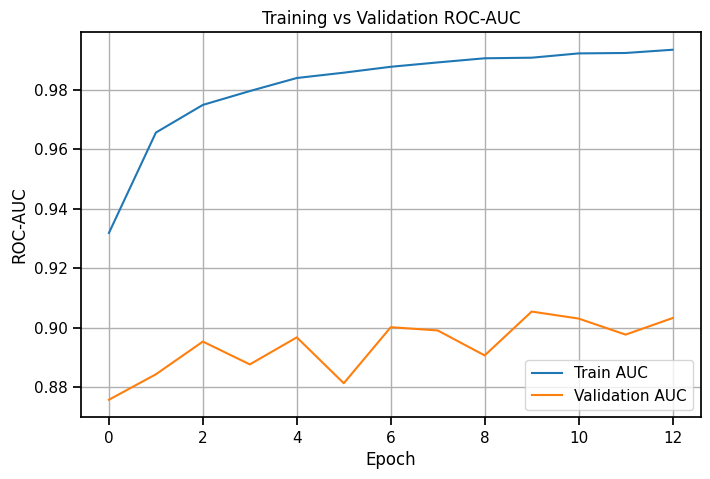

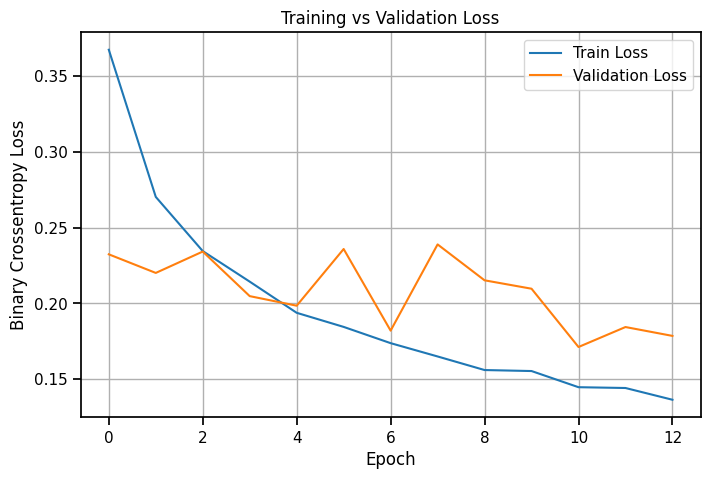

In [16]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

if "auc" in history_df.columns and "val_auc" in history_df.columns:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["auc"], label="Train AUC")
    plt.plot(history_df["val_auc"], label="Validation AUC")
    plt.title("Training vs Validation ROC-AUC")
    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.show()

if "loss" in history_df.columns and "val_loss" in history_df.columns:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["loss"], label="Train Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Crossentropy Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

The training curves help diagnose overfitting and underfitting. If training AUC keeps increasing while validation AUC stagnates or decreases, the model may be overfitting. If both curves remain low, the model may need more capacity, better features, longer training, or a larger tuning budget.

## 14. Threshold Tuning and Model Evaluation

Best threshold from validation F2-score: 0.8588
Best validation F2-score              : 0.5627

--- Validation Default Evaluation @ threshold=0.5000 ---
ROC-AUC: 0.9085
PR-AUC : 0.5829
              precision    recall  f1-score   support

           0     0.9912    0.9405    0.9652     20184
           1     0.2342    0.6847    0.3490       536

    accuracy                         0.9339     20720
   macro avg     0.6127    0.8126    0.6571     20720
weighted avg     0.9716    0.9339    0.9493     20720



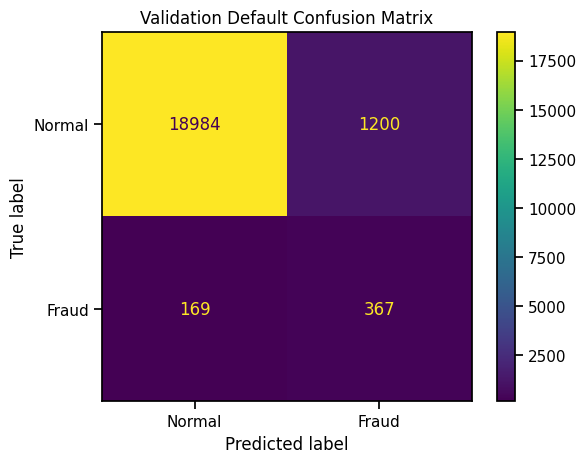


--- Validation Tuned Evaluation @ threshold=0.8588 ---
ROC-AUC: 0.9085
PR-AUC : 0.5829
              precision    recall  f1-score   support

           0     0.9893    0.9804    0.9848     20184
           1     0.4491    0.6007    0.5140       536

    accuracy                         0.9706     20720
   macro avg     0.7192    0.7906    0.7494     20720
weighted avg     0.9753    0.9706    0.9727     20720



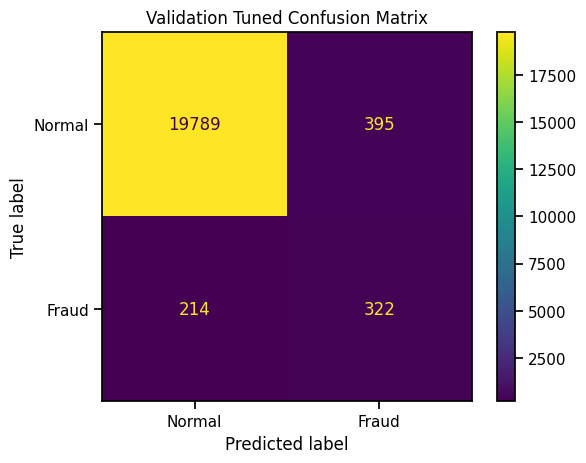


--- Test Default Evaluation @ threshold=0.5000 ---
ROC-AUC: 0.8966
PR-AUC : 0.5783
              precision    recall  f1-score   support

           0     0.9914    0.9435    0.9668     20184
           1     0.2454    0.6922    0.3623       536

    accuracy                         0.9370     20720
   macro avg     0.6184    0.8178    0.6646     20720
weighted avg     0.9721    0.9370    0.9512     20720



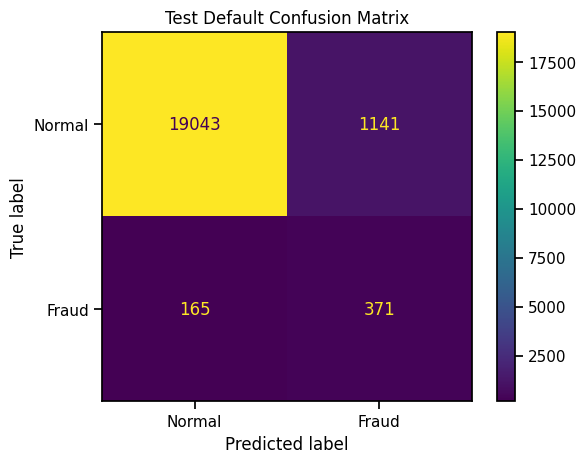


--- Test Tuned Evaluation @ threshold=0.8588 ---
ROC-AUC: 0.8966
PR-AUC : 0.5783
              precision    recall  f1-score   support

           0     0.9890    0.9805    0.9847     20184
           1     0.4443    0.5877    0.5060       536

    accuracy                         0.9703     20720
   macro avg     0.7166    0.7841    0.7454     20720
weighted avg     0.9749    0.9703    0.9723     20720



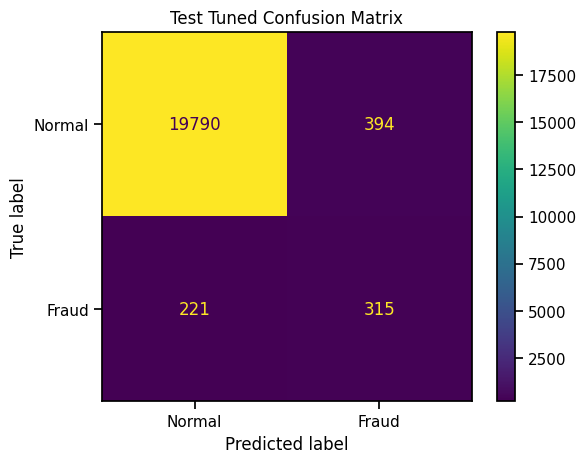

In [17]:
def find_best_threshold(y_true, proba, beta=2.0):
    """
    Select threshold using F-beta score.
    beta=2 prioritizes recall more than precision, which is commonly useful in fraud detection.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, proba)

    # thresholds length is len(precision)-1
    precision_t = precision[:-1]
    recall_t = recall[:-1]

    f_beta = (1 + beta**2) * (precision_t * recall_t) / (
        beta**2 * precision_t + recall_t + 1e-12
    )

    best_idx = int(np.nanargmax(f_beta))
    return float(thresholds[best_idx]), float(f_beta[best_idx])


best_threshold, best_f2 = find_best_threshold(y_val, val_proba, beta=2.0)
print(f"Best threshold from validation F2-score: {best_threshold:.4f}")
print(f"Best validation F2-score              : {best_f2:.4f}")


def evaluate_at_threshold(name, y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)

    roc_auc = roc_auc_score(y_true, proba)
    pr_auc = average_precision_score(y_true, proba)

    print(f"\n--- {name} Evaluation @ threshold={threshold:.4f} ---")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
    print(classification_report(y_true, pred, digits=4))

    cm = confusion_matrix(y_true, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])
    disp.plot(values_format="d")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    return {
        f"{name.lower()}_roc_auc": roc_auc,
        f"{name.lower()}_pr_auc": pr_auc
    }, pred


val_metrics_default, val_pred_default = evaluate_at_threshold(
    "Validation Default",
    y_val,
    val_proba,
    threshold=0.50
)

val_metrics_tuned, val_pred_tuned = evaluate_at_threshold(
    "Validation Tuned",
    y_val,
    val_proba,
    threshold=best_threshold
)

test_metrics_default, test_pred_default = evaluate_at_threshold(
    "Test Default",
    y_test,
    test_proba,
    threshold=0.50
)

test_metrics_tuned, test_pred_tuned = evaluate_at_threshold(
    "Test Tuned",
    y_test,
    test_proba,
    threshold=best_threshold
)

The neural network outputs fraud probability, so a threshold is required only when converting probabilities into class labels. The default threshold of 0.5 is compared with a validation-tuned threshold using F2-score. F2-score gives more weight to recall, which is often appropriate in fraud detection because missing fraudulent transactions can be more costly than flagging additional transactions for review.

## 15. ROC Curve and Precision-Recall Curve

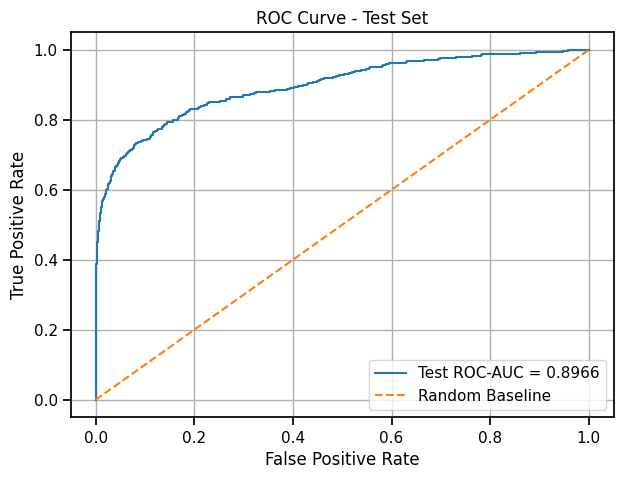

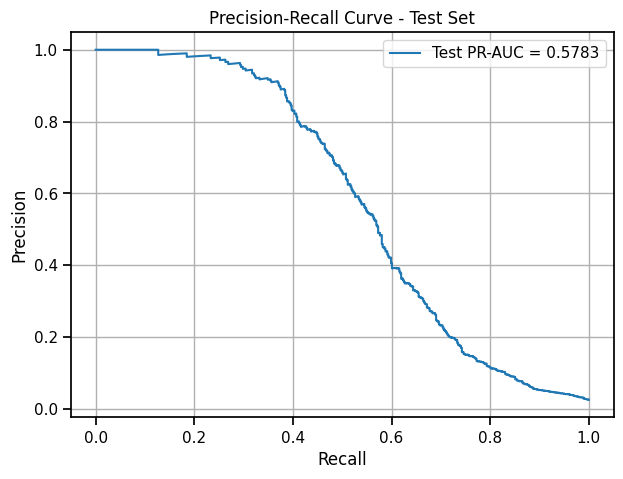

In [18]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Test ROC-AUC = {roc_auc_score(y_test, test_proba):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Baseline")
plt.title("ROC Curve - Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, test_proba)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Test PR-AUC = {average_precision_score(y_test, test_proba):.4f}")
plt.title("Precision-Recall Curve - Test Set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

ROC-AUC measures how well the model ranks fraudulent transactions above normal transactions across all thresholds. Precision-Recall AUC is especially important for imbalanced data because it focuses on the positive fraud class. A high ROC-AUC with a low PR-AUC may indicate that the model ranks generally well but still struggles to retrieve fraud cases with acceptable precision.

## 16. Save Model, Preprocessing Artifacts, and Predictions

In [19]:
# Save final Keras model
model_path = OUTPUT_DIR / "fraud_detection_tabular_dl.keras"
final_model.save(model_path)

# Save preprocessing artifacts
preprocess_artifacts = {
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "drop_cols": drop_cols,
    "category_maps": category_maps,
    "cat_cardinalities": cat_cardinalities,
    "num_imputer": num_imputer,
    "num_scaler": num_scaler,
    "missing_token": MISSING_TOKEN,
    "rare_token": RARE_TOKEN,
    "missing_drop_threshold": MISSING_DROP_THRESHOLD,
    "min_category_count": MIN_CATEGORY_COUNT,
    "max_category_levels": MAX_CATEGORY_LEVELS,
    "use_smote": USE_SMOTE,
    "smote_sampling_strategy": SMOTE_SAMPLING_STRATEGY,
    "smote_k_neighbors": SMOTE_K_NEIGHBORS,
    "best_threshold": best_threshold,
}

preprocess_path = OUTPUT_DIR / "preprocessing_artifacts.joblib"
joblib.dump(preprocess_artifacts, preprocess_path)

# Save feature metadata as JSON for readability
feature_metadata = {
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "drop_cols": drop_cols,
    "cat_cardinalities": [int(x) for x in cat_cardinalities],
    "best_threshold": float(best_threshold),
    "use_smote": bool(USE_SMOTE),
    "smote_sampling_strategy": float(SMOTE_SAMPLING_STRATEGY),
    "smote_k_neighbors": int(SMOTE_K_NEIGHBORS),
    "original_train_rows": int(len(y_train)),
    "resampled_train_rows": int(len(y_train_balanced)),
    "model_type": "Keras tabular neural network with categorical embeddings and SMOTE/SMOTENC",
}

metadata_path = OUTPUT_DIR / "feature_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(feature_metadata, f, indent=2)

# Save holdout predictions
prediction_df = pd.DataFrame({
    "y_true": np.asarray(y_test).astype(int),
    "fraud_probability": test_proba,
    "prediction_threshold_0_5": test_pred_default,
    "prediction_threshold_tuned": test_pred_tuned,
})

prediction_path = OUTPUT_DIR / "test_predictions.csv"
prediction_df.to_csv(prediction_path, index=False)

print("✅ Model dan artifact berhasil disimpan:")
print("-", model_path)
print("-", preprocess_path)
print("-", metadata_path)
print("-", prediction_path)
display(prediction_df.head())

✅ Model dan artifact berhasil disimpan:
- outputs/fraud_detection_tabular_dl.keras
- outputs/preprocessing_artifacts.joblib
- outputs/feature_metadata.json
- outputs/test_predictions.csv


,y_true,fraud_probability,prediction_threshold_0_5,prediction_threshold_tuned
0,0,0.002180,0,0
1,0,0.000025,0,0
2,0,0.000572,0,0
3,0,0.022146,0,0
4,0,0.009463,0,0


The final model is saved in Keras format, while preprocessing objects are saved using Joblib. Saving preprocessing artifacts is essential because the same imputation, scaling, category mapping, and threshold must be reused during inference. The SMOTE configuration is saved only as training metadata because SMOTE is not applied during inference. The prediction CSV stores holdout test probabilities and class predictions for both the default and tuned thresholds.

## 17. Log Final Artifacts to MLflow

In [22]:
import inspect
from mlflow.store.artifact.artifact_repository_registry import _artifact_repository_registry

def _make_compatible_builder(original_builder):
    sig = inspect.signature(original_builder)
    accepted = set(sig.parameters.keys())

    def compatible_builder(artifact_uri, tracking_uri=None, registry_uri=None):
        kwargs = {}
        if "tracking_uri" in accepted:
            kwargs["tracking_uri"] = tracking_uri
        if "registry_uri" in accepted:
            kwargs["registry_uri"] = registry_uri
        return original_builder(artifact_uri, **kwargs)
    return compatible_builder

for _scheme, _builder in list(_artifact_repository_registry._registry.items()):
    if not getattr(_builder, "_patched_for_tracking_uri", False):
        _wrapped = _make_compatible_builder(_builder)
        _wrapped._patched_for_tracking_uri = True
        _artifact_repository_registry._registry[_scheme] = _wrapped

print("✅ Artifact repository registry sudah dipatch.")

active_run = mlflow.active_run()

if active_run is None:
    run_context = mlflow.start_run(run_name="final_artifact_logging")
else:
    run_context = None

try:
    mlflow.log_artifact(str(model_path))
    mlflow.log_artifact(str(preprocess_path))
    mlflow.log_artifact(str(metadata_path))
    mlflow.log_artifact(str(prediction_path))

    try:
        mlflow.tensorflow.log_model(final_model, artifact_path="keras_model")
        print("✅ Keras model logged to MLflow.")
    except Exception as e:
        print("⚠️ MLflow model logging skipped, but local model artifact is saved.")
        print("Reason:", e)

    mlflow.log_metric("best_validation_threshold_f2", float(best_threshold))
    mlflow.log_metric("test_roc_auc_final", float(roc_auc_score(y_test, test_proba)))
    mlflow.log_metric("test_pr_auc_final", float(average_precision_score(y_test, test_proba)))

finally:
    if run_context is not None:
        mlflow.end_run()

print("✅ Final artifacts logged to MLflow.")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

✅ Artifact repository registry sudah dipatch.


2026/06/20 13:58:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


⚠️ MLflow model logging skipped, but local model artifact is saved.
Reason: API request to endpoint /api/2.0/mlflow/logged-models failed with error code 404 != 200. Response body: ''
🏃 View run final_artifact_logging at: https://southeastasia.api.azureml.ms/mlflow/v2.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas/#/experiments/27a264b8-1e31-4ad0-bb7f-d012d9c5f24c/runs/20cae0da-6497-402e-b9ab-514a1d170bc6
🧪 View experiment at: https://southeastasia.api.azureml.ms/mlflow/v2.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas/#/experiments/27a264b8-1e31-4ad0-bb7f-d012d9c5f24c
✅ Final artifacts logged to MLflow.
MLflow tracking URI: azureml://southeastasia.api.azureml.ms/mlflow/v1.0/subscriptions/3f99b127-d385-4c2f-8d98-0ffa0857a021/resourceGroups/uas/providers/Microsoft.MachineLearningServices/workspaces/uas


This final MLflow cell logs the trained model, preprocessing artifacts, feature metadata, predictions, and final metrics. In AzureML, these logs can be associated with the experiment run when MLflow tracking is configured. Locally, they are stored under the notebook's MLflow tracking directory.

## 18. Inference Helper for New Transaction Data

In [23]:
def preprocess_new_transactions(raw_df: pd.DataFrame, artifacts: dict):
    """
    Transform new transaction rows using saved preprocessing artifacts.
    raw_df must follow the train_transaction.csv feature schema, excluding isFraud.
    """
    df = add_transaction_features(raw_df)

    if TARGET_COL in df.columns:
        df = df.drop(columns=[TARGET_COL])
    if ID_COL in df.columns:
        transaction_ids = df[ID_COL].copy()
        df = df.drop(columns=[ID_COL])
    else:
        transaction_ids = None

    df = df.drop(columns=[col for col in artifacts["drop_cols"] if col in df.columns], errors="ignore")

    for col in artifacts["num_cols"] + artifacts["cat_cols"]:
        if col not in df.columns:
            df[col] = np.nan

    df = df[artifacts["num_cols"] + artifacts["cat_cols"]]

    if len(artifacts["num_cols"]) > 0:
        num_array = artifacts["num_imputer"].transform(df[artifacts["num_cols"]])
        num_array = artifacts["num_scaler"].transform(num_array).astype("float32")
    else:
        num_array = np.zeros((len(df), 0), dtype="float32")

    cat_array = transform_categories(df, artifacts["cat_cols"], artifacts["category_maps"])

    return num_array, cat_array, transaction_ids


def predict_fraud_probability(raw_df: pd.DataFrame, model: keras.Model, artifacts: dict, batch_size: int = 1024):
    X_new_num, X_new_cat, transaction_ids = preprocess_new_transactions(raw_df, artifacts)
    ds_new = make_tf_dataset(X_new_num, X_new_cat, y_values=None, batch_size=batch_size, shuffle=False)
    probabilities = model.predict(ds_new, verbose=0).ravel()
    predictions = (probabilities >= artifacts["best_threshold"]).astype(int)

    result = pd.DataFrame({
        "fraud_probability": probabilities,
        "isFraud_predicted": predictions
    })

    if transaction_ids is not None:
        result.insert(0, ID_COL, transaction_ids.values)

    return result


print("✅ Inference helper siap digunakan untuk data transaksi baru.")

✅ Inference helper siap digunakan untuk data transaksi baru.


The inference helper demonstrates how the saved preprocessing logic should be reused for future transaction data. The same feature engineering, selected columns, imputation, scaling, category mapping, and tuned threshold are applied before generating fraud probabilities. This makes the workflow more deployment-oriented and closer to an end-to-end production pipeline.